# Time series forecasting with PatchTST-FM

This notebook demonstrates how to use PatchTST-FM in a time series forecasting task using the forecasting pipeline.  PatchTST-FM (patched time-series transformer-based foundation model) essentially has the architectural simplicity of PatchTST, but differs in some crucial ways. Coupled with a revised training strategy and a significantly larger training corpus, we are able to train a model that achieves state-of-the-art results on GiftEval.

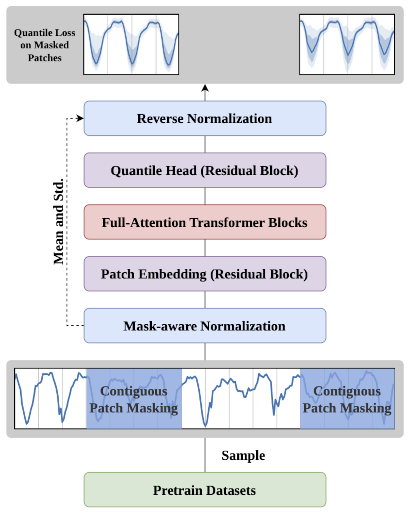

More details about the model and its components can be found in our paper:
[Yunshi Wen, Wesley M. Gifford, Chandra Reddy, Lam M. Nguyen, Jayant Kalagnanam, and Anak Agung Julius, "Revisiting the Generic Transformer: Deconstructing a Strong Baseline for Time Series Foundation Models," arXiv preprint arXiv:2602.06909, 6 Feb. 2026.](https://arxiv.org/abs/2602.06909)

## Preparing the experiments

To get started, please follow the installation instructions from [here](https://github.com/ibm-granite/granite-tsfm/?tab=readme-ov-file#initial-setup).

Import the necessary dependencies

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from tsfm_public import PatchTSTFMForPrediction, TimeSeriesForecastingPipeline
from tsfm_public.toolkit.time_series_preprocessor import create_timestamps, prepare_data_splits

Load and prepare the data

In [2]:
# Model configurations
model_name = "ibm-research/patchtst-fm-r1"

# Auxiliary configurations
seed = 0
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.mps.is_available() else "cpu")
print(f"Device: {device}")

dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
timestamp_column = "date"
id_columns = []  # mention the ids that uniquely identify a time-series.
target_columns = ["HUFL"]  # , "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

# prepare data splits according to the original example, but with revised context length
context_length = 4096
prediction_length = 96
split_config = {
    "train": [0, 8640],
    "valid": [8640, 11520],
    "test": [
        11520,
        14400,
    ],
}

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)
train_df, valid_df, test_df = prepare_data_splits(data, context_length=context_length, split_config=split_config)

batch_size = 16

Device: mps


## Simple forecast with TimeSeriesForecastingPipeline

Load the model using the standard HuggingFace interface.

In [3]:
model = PatchTSTFMForPrediction.from_pretrained(model_name)

In [4]:
all_data = test_df.iloc[: context_length + prediction_length + 10]  # take a smaller portion of the data

### Create a forecast using the forecasting pipeline

Here we pass information about the dataset columns, including:  
`timestamp_column`: column containing the timestamp  
`target_column`: target we want to forecast  

We also provide some options for how the data should be fed to the model:  
`max_context_length`: maximum size of the data to feed to the model, here we use the maximum consumable by the model (8192) -- this means context vectors up to this size will be passed.  
`context_length`: effectively the minimum amount of context provided to the model.  
`prediction_length`: length of predictions to generate.  
`imput_methd`: imptuation done during torch dataset creation. Here we choose None since PatchTST-FM can automatically impute the data.  
`quantile_levels`: quantiles chosen from among those used during pretraining (0.01 to 0.99 in increments of 0.01). For simplicity we choose two quantiles 0.1 and 0.9 and the median.  


In [5]:
pipe = TimeSeriesForecastingPipeline(
    model=model,
    id_columns=[],
    timestamp_column=timestamp_column,
    target_columns=target_columns,
    max_context_length=model.config.context_length,
    context_length=context_length,
    prediction_length=prediction_length,
    batch_size=batch_size,
    impute_method=None,
    device=device,
    quantile_levels=[0.1, 0.5, 0.9],
)

forecast_pipe = pipe(all_data)

Device set to use mps
INFO:p-69284:t-8741118528:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 4096, 'frequency_token': None, 'id_columns': [], 'timestamp_column': 'date', 'target_columns': ['HUFL'], 'impute_method': None, 'max_context_length': 8192}
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 96 | Input is tensor: True
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 96 | Input is tensor: True
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 96 | Input is tensor: True
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 96 | Input is tensor: True
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 96 | Input is tensor: True
INFO:p-69284:t-8741118528:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len

In [6]:
forecast_pipe.head()

,date,HUFL_prediction,HUFL,HUFL_prediction_q0.1,HUFL_prediction_q0.5,HUFL_prediction_q0.9
0,2017-10-23 23:00:00,"[10.136058807373047, 9.955644607543945, 9.3697...","[9.979999542236328, 8.305999755859375, 8.77400...","[9.301806449890137, 8.800004005432129, 8.31833...","[10.117172241210938, 9.936872482299805, 9.3384...","[11.184808731079102, 11.26458740234375, 10.662..."
1,2017-10-24 00:00:00,"[10.000105857849121, 9.641778945922852, 9.7849...","[8.305999755859375, 8.77400016784668, 8.104999...","[9.237415313720703, 8.562524795532227, 8.75042...","[10.001720428466797, 9.618375778198242, 9.8069...","[10.978446960449219, 10.907094955444336, 11.01..."
2,2017-10-24 01:00:00,"[8.281508445739746, 8.834628105163574, 8.65245...","[8.77400016784668, 8.104999542236328, 8.439000...","[7.258962631225586, 7.412045955657959, 7.15561...","[8.282527923583984, 8.862966537475586, 8.71747...","[9.468484878540039, 10.289688110351562, 10.226..."
3,2017-10-24 02:00:00,"[9.172699928283691, 9.222954750061035, 9.49073...","[8.104999542236328, 8.439000129699707, 8.43900...","[8.453481674194336, 8.083744049072266, 8.23594...","[9.240961074829102, 9.268829345703125, 9.61856...","[10.027839660644531, 10.423681259155273, 10.81..."
4,2017-10-24 03:00:00,"[8.089512825012207, 8.992715835571289, 9.53298...","[8.439000129699707, 8.439000129699707, 9.64500...","[6.972629547119141, 7.292092800140381, 7.60915...","[8.157539367675781, 9.141395568847656, 9.75419...","[9.2758207321167, 10.565954208374023, 11.30970..."


## Plot the results

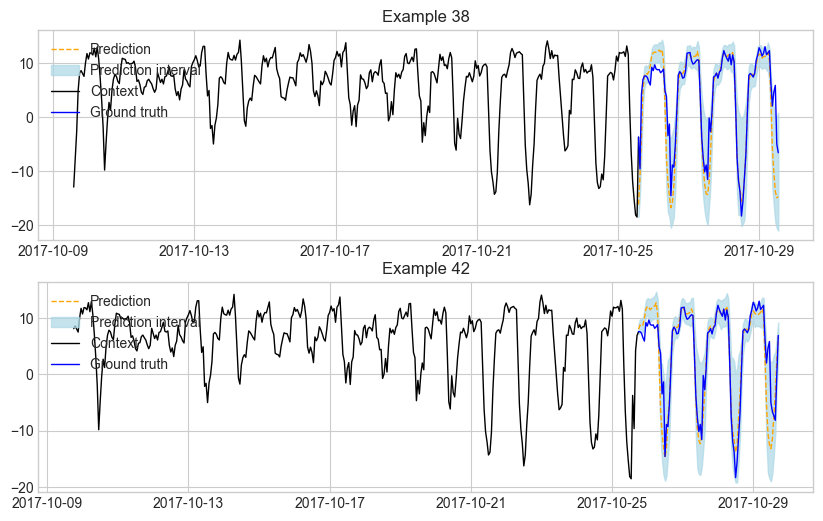

In [7]:
# plotting
plt.style.use("seaborn-v0_8-whitegrid")

indices = [38, 42]

plot_context = 4 * prediction_length
num_plots = len(indices)
freq = "h"
channel = "HUFL"
channel_pred = "HUFL_prediction_q0.5"  # for mean use "HUFL_prediction"
channel_lower = "HUFL_prediction_q0.1"
channel_upper = "HUFL_prediction_q0.9"


gt_df = test_df.copy()
gt_df = gt_df.set_index(timestamp_column)
forecast = forecast_pipe

fig, axs = plt.subplots(num_plots, 1, figsize=(10, 3 * num_plots))

for i, idx in enumerate(indices):
    this_forecast = forecast.iloc[idx]  # forecast[forecast["id"] == idx].iloc[0]
    ts_y_hat = create_timestamps(this_forecast[timestamp_column], freq=freq, periods=prediction_length)

    y_hat = this_forecast[channel_pred]
    y_hat_lower = this_forecast[channel_lower]
    y_hat_upper = this_forecast[channel_upper]

    loc = gt_df.index.get_loc(this_forecast[timestamp_column])
    ts_index = gt_df.index[loc - plot_context + 1 : loc + 2]  #  + prediction_length]
    y = gt_df.loc[ts_index][channel]
    ts_y = y.index
    y = y.values

    ts_index = gt_df.index[loc + 1 : loc + 1 + prediction_length]
    y2 = gt_df.loc[ts_index][channel]
    ts_y2 = y2.index
    y2 = y2.values

    axs[i].plot(ts_y_hat, y_hat, label="Prediction", linestyle="--", color="orange", linewidth=1)
    axs[i].fill_between(
        ts_y_hat, y_hat_lower, y_hat_upper, label="Prediction interval", alpha=0.7, color="lightblue", linewidth=1
    )

    axs[i].plot(ts_y, y, label="Context", linestyle="-", color="black", linewidth=1)
    axs[i].plot(ts_y2, y2, label="Ground truth", linestyle="-", color="blue", linewidth=1)
    axs[i].set_title(f"Example {idx}")
    axs[i].legend(loc="upper left")

## Links
* Library: [Granite TSFM on Github](https://github.com/ibm-granite/granite-tsfm)
* Model: [PatchTST-FM on HuggingFace](https://huggingface.co/ibm-research/patchtst-fm-r1)
* Dataset: [Electrical Transformer Dataset](https://github.com/zhouhaoyi/ETDataset)